In [2]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import EarlyStoppingCallback

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

# -----------------------
# A) Load your JSONL file
# -----------------------
# This reads each JSON line as one training example.
data_files = {
    "train": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/train.jsonl",
    "validation": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/val.jsonl",
    "test": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/test.jsonl",
}
ds = load_dataset("json", data_files=data_files)


# -----------------------
# B) Label mapping
# -----------------------
label_list = ["entailment", "contradiction", "neutral"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

def add_label_id(example):
    example["label"] = label2id[example["label"]]
    return example

ds = ds.map(add_label_id)

# -----------------------
# C) Tokenizer
# -----------------------
# Tokenizer turns Hebrew text into numbers the model understands.
model_name = "avichr/heBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# -----------------------
# D) Model for 3-class classification - MOVED HERE
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Ensure PAD exists (some checkpoints are missing it)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# If tokenizer has more tokens than model embeddings, resize
if len(tokenizer) != model.config.vocab_size:
    model.resize_token_embeddings(len(tokenizer))

print("AFTER FIX -> model vocab_size:", model.config.vocab_size, "tokenizer len:", len(tokenizer))
print("pad token:", tokenizer.pad_token, "pad_id:", tokenizer.pad_token_id)


def tokenize_pair(example):
    return tokenizer(
        example["translation1"],
        example["translation2"],
        truncation=True,
        max_length=128,
    )

ds_tok = ds.map(tokenize_pair, batched=False)
cols = ["input_ids", "attention_mask", "label"]
ds_tok = ds_tok.remove_columns([c for c in ds_tok["train"].column_names if c not in cols])

def find_bad_example(split="train", limit=10000):
    emb_size = model.get_input_embeddings().weight.shape[0]
    ds_split = ds_tok[split]
    n = min(limit, len(ds_split))

    for i in range(n):
        ids = ds_split[i]["input_ids"]
        mx = max(ids)
        mn = min(ids)
        if mn < 0 or mx >= emb_size:
            print("BAD EXAMPLE FOUND!")
            print("split:", split, "index:", i)
            print("min_id:", mn, "max_id:", mx, "emb_size:", emb_size)
            print("translation1:", ds[split][i]["translation1"])
            print("translation2:", ds[split][i]["translation2"])
            print("input_ids:", ids[:80], "...")
            return i

    print(f"No bad examples found in first {n} rows of {split}")
    return None

find_bad_example("train")
find_bad_example("validation")
find_bad_example("test")


# This pads batches nicely (so all examples in a batch have same length).
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# -----------------------
# E) Metrics (what “results” you’ll see)
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# -----------------------
# F) Training settings
# -----------------------
args = TrainingArguments(
    output_dir="alephbert_final_fulltrain",
    learning_rate=2.672199003998088e-05,
    warmup_ratio=0.036878291253257145,
    weight_decay=0.027242344036400676,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=True,# האצה של פי 2-3 ב-A100
)


# -----------------------
# G) Trainer (does the training loop)
# -----------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.02)]
)

# -----------------------
# H) Train + Evaluate
# -----------------------
trainer.train()

print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_labels = test_out.label_ids
test_preds = np.argmax(test_logits, axis=-1)

print(classification_report(test_labels, test_preds, target_names=label_list, digits=4))
print("Confusion matrix (rows=true, cols=pred) label order:", label_list)
print(confusion_matrix(test_labels, test_preds))

# -----------------------
# I) Per-genre results (nice for your report)
# -----------------------
test_genres = ds["test"]["genre"]
print("\nPer-genre macro-F1:")
for g in sorted(set(test_genres)):
    idx = [i for i, gg in enumerate(test_genres) if gg == g]
    g_labels = test_labels[idx]
    g_preds = test_preds[idx]
    g_f1 = f1_score(g_labels, g_preds, average="macro")
    print(f"  {g:12s} n={len(idx):4d} macro_f1={g_f1:.4f}")

# -----------------------
# J) Save the model (required deliverable)
# -----------------------
trainer.save_model("/content/drive/MyDrive/nlp_pro2/saved/heBERT_nli_full_best_early_stopping")
tokenizer.save_pretrained("/content/drive/MyDrive/nlp_pro2/saved/heBERT_nli_full_best_early_stopping")
print('saving the modal!')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/99999 [00:00<?, ? examples/s]

Map:   0%|          | 0/21429 [00:00<?, ? examples/s]

...

No bad examples found in first 10000 rows of train
No bad examples found in first 10000 rows of validation
No bad examples found in first 10000 rows of test


/tmp/ipython-input-1333671603.py:146: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.762300,0.736258,0.689720,0.688645
2,0.621500,0.721519,0.706379,0.705658
3,0.437800,0.859070,0.698773,0.698705



FINAL TEST RESULTS:


               precision    recall  f1-score   support

   entailment     0.6856    0.7767    0.7283      7211
contradiction     0.7569    0.6573    0.7036      7114
      neutral     0.6865    0.6844    0.6855      7104

     accuracy                         0.7065     21429
    macro avg     0.7097    0.7061    0.7058     21429
 weighted avg     0.7096    0.7065    0.7059     21429

Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[5601  628  982]
 [1200 4676 1238]
 [1368  874 4862]]

Per-genre macro-F1:
  fiction      n=5202 macro_f1=0.6860
  government   n=5439 macro_f1=0.7297
  letters      n= 139 macro_f1=0.7825
  nineeleven   n= 131 macro_f1=0.7027
  oup          n= 138 macro_f1=0.6967
  slate        n=5018 macro_f1=0.6758
  travel       n=5362 macro_f1=0.7268
saving the modal!


# Evaluation

**Confusion Matrix**

In [4]:
# finding fp/fn per label
import numpy as np

labels = ["entailment","contradiction","neutral"]
for i, name in enumerate(labels):
    fp = np.sum((test_preds == i) & (test_labels != i))
    fn = np.sum((test_preds != i) & (test_labels == i))
    tp = np.sum((test_preds == i) & (test_labels == i))
    tn = np.sum((test_preds != i) & (test_labels != i))
    print(f"{name:13s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")

entailment    TP=5601 FP=2568 FN=1610 TN=11650
contradiction TP=4676 FP=1502 FN=2438 TN=12813
neutral       TP=4862 FP=2220 FN=2242 TN=12105


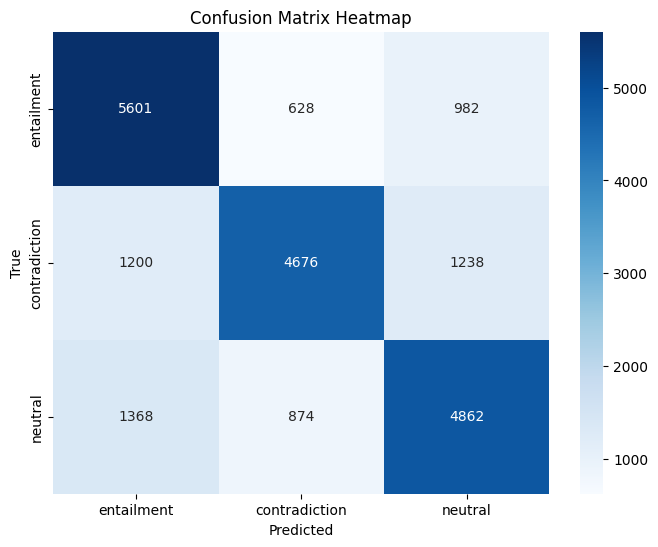

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# יצירת Heatmap למטריצת הבלבול
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**AUC-ROC**

In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# One-vs-Rest ROC AUC
auc_macro_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="weighted")

print("ROC-AUC macro (OvR):", auc_macro_ovr)
print("ROC-AUC weighted (OvR):", auc_weighted_ovr)

ROC-AUC macro (OvR): 0.8677787187708607
ROC-AUC weighted (OvR): 0.8678461646104284


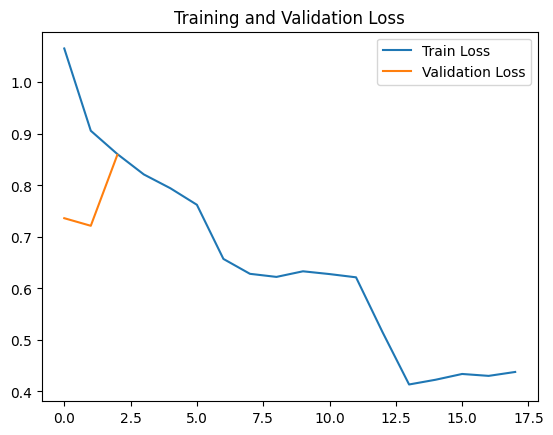

In [7]:
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

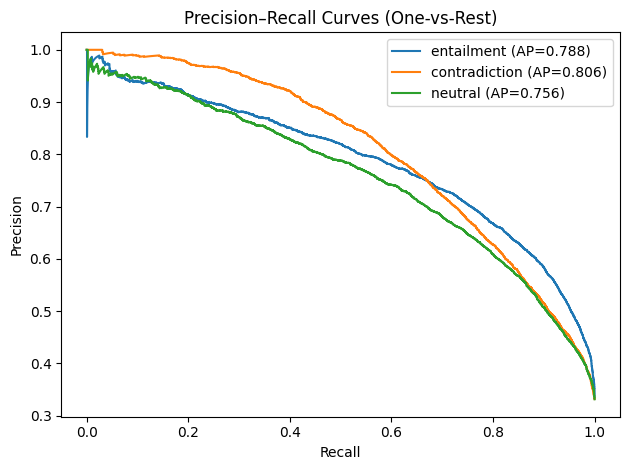

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true_bin = label_binarize(test_labels, classes=[0,1,2])  # shape (N,3)

plt.figure()
for i, name in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

inv_id2label = {0:"entailment", 1:"contradiction", 2:"neutral"}

rows = []
for i in range(len(test_labels)):
    true_id = int(test_labels[i])
    pred_id = int(test_preds[i])
    if true_id != pred_id:
        rows.append({
            "i": i,
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": inv_id2label[true_id],
            "pred": inv_id2label[pred_id],
            "pred_conf": float(probs[i, pred_id]),
            "true_conf": float(probs[i, true_id]),
            "margin": float(probs[i, pred_id] - probs[i, true_id]),
        })

err_df = pd.DataFrame(rows)
print("Total errors:", len(err_df))

Total errors: 6290


In [10]:
print(f"% of mistakes: {6130/21429}")

% of mistakes: 0.28606094544775773


Examples:

In [11]:
print("Total errors:", len(err_df))
err_df.head(3)

Total errors: 6290


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
0,0,fiction,מזל בשביל דרו שלא היו עדים נוספים עכשיו; הדמיו...,לדרו היתה תקופה של מזל רע כאשר היו לפחות תריסר...,contradiction,neutral,0.381773,0.378063,0.003710
1,1,fiction,"אבל שפטתי שחשוב לא לבזבז זמן."" וכמה שיותר בתמצ...",הוא סיפר סיפור ארוך מאוד על החוויות האחרונות שלו.,contradiction,neutral,0.616833,0.206613,0.410220
2,4,travel,"ב-1967 פננג נפגעה ממהומות רציניות, שהדגישו את ...",פננג היא עיר גדולה ופורחת ביבשת סין.,neutral,contradiction,0.564066,0.415307,0.148759


In [12]:
print("\nTop 5 confidently wrong:")
display(err_df.sort_values("pred_conf", ascending=False).head(5))

print("\nTop 5 ambiguous (small margin):")
display(err_df.sort_values("margin", ascending=True).head(5))



Top 5 confidently wrong:


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
3066,10379,government,מנהלי התוכניות הטובים ביותר באמריקה הם אלה שמס...,לקליימן אין דעה על מנהלי התוכניות הבריטיים.,neutral,contradiction,0.992192,0.006305,0.985887
32,101,slate,"לדעתם, זה היה עוזר.","לדעתי, זה לא היה עוזר.",neutral,contradiction,0.992134,0.005596,0.986537
3628,12297,travel,תיירות היא כיום התעשייה הגדולה ביותר באזור האג...,תיירות מעולם לא הייתה התעשייה הגדולה ביותר באז...,neutral,contradiction,0.991609,0.006675,0.984934
1769,5879,travel,אבל אלה מרשימים בפני עצמם והמדריכים הצעירים המ...,"בחורף, אין מדריכים דוברי אנגלית בקלוני.",neutral,contradiction,0.991533,0.006655,0.984878
1914,6410,government,החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפ...,טכנולוגיה לא הוזכרה בחלק הראשון.,neutral,contradiction,0.991251,0.007138,0.984113



Top 5 ambiguous (small margin):


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
3447,11742,government,"עם זאת, לא נראה ששינוי יגרום להשפעה שלילית, מא...",חברות תעופה מציעות מיילים לטיסות חוזרות כתמריץ.,neutral,contradiction,0.367557,0.367378,0.000179
4581,15436,government,העלות הקבועה,העלות קבועה.,entailment,contradiction,0.458093,0.457869,0.000224
725,2418,slate,אבל האם לא את התעמולה הנפוצה הזו לעגנו ולגלגנו...,"ייתכן שאנו חושבים שזה סביר לפעול בדרך זו, אבל ...",neutral,entailment,0.489792,0.489553,0.000239
2517,8589,fiction,'אני לא סומך עליהם שיעמדו בחלק שלהם בעסקה.,"אף על פי שאמרו שישמרו על הבטחתם, הרגשתי קצת לא...",neutral,entailment,0.425338,0.425026,0.000311
5172,17522,travel,"בחוף המערבי עצמו, ההימורים הטובים ביותר שלכם ה...",אתרי הנופש בפננג פנגקור ואיי לנגקאווי פופולריי...,neutral,entailment,0.495153,0.494670,0.000483


There are 2 ways to check the mistakes:


1.   by the confidence - where the confidence is the the biggest
2.   to check by labels - to see where the model most mistaken



# Option 1

In [13]:
target = "neutral"
target_id = labels.index(target)

pred_neutral_idx = np.where(test_preds == target_id)[0]
avg_conf_pred_neutral = probs[pred_neutral_idx, target_id].mean()
print("Avg confidence when predicting neutral:", avg_conf_pred_neutral)

true_neutral_idx = np.where(test_labels == target_id)[0]
avg_conf_true_neutral = probs[true_neutral_idx, target_id].mean()
print("Avg confidence on TRUE neutral examples:", avg_conf_true_neutral)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]
avg_conf_fp = probs[fp_idx, target_id].mean() if len(fp_idx) else float("nan")
avg_conf_fn = probs[fn_idx, target_id].mean() if len(fn_idx) else float("nan")
print("Avg P(neutral) for FP neutral:", avg_conf_fp)
print("Avg P(neutral) for FN neutral:", avg_conf_fn)

avg_wrong_conf_fn = probs[fn_idx, test_preds[fn_idx]].mean() if len(fn_idx) else float("nan")
print("Avg confidence in the WRONG predicted label (on FN neutral):", avg_wrong_conf_fn)

Avg confidence when predicting neutral: 0.7640465
Avg confidence on TRUE neutral examples: 0.61622167
Avg P(neutral) for FP neutral: 0.675034
Avg P(neutral) for FN neutral: 0.20750959
Avg confidence in the WRONG predicted label (on FN neutral): 0.68802875


In [14]:
# option 1
import numpy as np
import pandas as pd
from scipy.special import softmax

label_list = ["entailment", "contradiction", "neutral"]
id2label = {i:l for i,l in enumerate(label_list)}

# test_logits, test_labels, test_preds must already exist
probs = softmax(test_logits, axis=1)  # shape (N, 3)

In [15]:
# option 1 exapmls
# Top 15 confident wrong predictions
top_conf_errors = err_df.sort_values("pred_conf", ascending=False).head(15)

for _, r in top_conf_errors.iterrows():
    print("\n" + "="*80)
    print(f"Index {r['i']} | genre={r['genre']}")
    print(f"TRUE={r['true']} | PRED={r['pred']} | pred_conf={r['pred_conf']:.3f} | true_conf={r['true_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


Index 10379 | genre=government
TRUE=neutral | PRED=contradiction | pred_conf=0.992 | true_conf=0.006
t1: מנהלי התוכניות הטובים ביותר באמריקה הם אלה שמסוגלים להתאים את עצמם למציאות של הזמן, אמר קליימן.
t2: לקליימן אין דעה על מנהלי התוכניות הבריטיים.

Index 101 | genre=slate
TRUE=neutral | PRED=contradiction | pred_conf=0.992 | true_conf=0.006
t1: לדעתם, זה היה עוזר.
t2: לדעתי, זה לא היה עוזר.

Index 12297 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.992 | true_conf=0.007
t1: תיירות היא כיום התעשייה הגדולה ביותר באזור האגמים.
t2: תיירות מעולם לא הייתה התעשייה הגדולה ביותר באזור האגמים.

Index 5879 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.992 | true_conf=0.007
t1: אבל אלה מרשימים בפני עצמם והמדריכים הצעירים המצוינים של קלני (דוברי אנגלית בקיץ) עוזרים לנו לתפוס את השאר.
t2: בחורף, אין מדריכים דוברי אנגלית בקלוני.

Index 6410 | genre=government
TRUE=neutral | PRED=contradiction | pred_conf=0.991 | true_conf=0.007
t1: החלק השני דן בתפקיד של הטכנולוגיה

In [16]:
# option 1 to check if negative with the used of (no/not) in one t1 and not the other is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues
import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")

def has_neg(s):
    return bool(NEG_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have negation flip: 18


,true,pred,pred_conf,t1,t2
3066,neutral,contradiction,0.992192,מנהלי התוכניות הטובים ביותר באמריקה הם אלה שמס...,לקליימן אין דעה על מנהלי התוכניות הבריטיים.
32,neutral,contradiction,0.992134,"לדעתם, זה היה עוזר.","לדעתי, זה לא היה עוזר."
3628,neutral,contradiction,0.991609,תיירות היא כיום התעשייה הגדולה ביותר באזור האג...,תיירות מעולם לא הייתה התעשייה הגדולה ביותר באז...
1769,neutral,contradiction,0.991533,אבל אלה מרשימים בפני עצמם והמדריכים הצעירים המ...,"בחורף, אין מדריכים דוברי אנגלית בקלוני."
1914,neutral,contradiction,0.991251,החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפ...,טכנולוגיה לא הוזכרה בחלק הראשון.


In [17]:
# החלת הפונקציה על כל הטעויות
err_df["neg_flip"] = err_df.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

# חישוב הכמות הכוללת והאחוז מתוך כלל הטעויות
total_neg_flip_errors = err_df["neg_flip"].sum()
percent_of_errors = (total_neg_flip_errors / len(err_df)) * 100

print(f"סה''כ טעויות עם 'היפוך שלילה': {total_neg_flip_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

# בדיקה: באילו מחלקות המודל הכי מתבלבל כשיש שלילה?
neg_error_dist = err_df[err_df["neg_flip"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות שלילה (אמת מול חיזוי):")
display(neg_error_dist)

סה''כ טעויות עם 'היפוך שלילה': 1264
אחוז מתוך כלל הטעויות: 20.10%

התפלגות טעויות שלילה (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,168,256
entailment,210,0,159
neutral,322,149,0


In [18]:
# option 1 to check if sentences include dates, the model may ignore them and this is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues
import re

TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def has_neg(s):
    return bool(TEMP_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have negation flip: 0


,true,pred,pred_conf,t1,t2


In [19]:
# החלת הפונקציה על כל הטעויות
err_df["neg_flip"] = err_df.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

# חישוב הכמות הכוללת והאחוז מתוך כלל הטעויות
total_neg_flip_errors = err_df["neg_flip"].sum()
percent_of_errors = (total_neg_flip_errors / len(err_df)) * 100

print(f"סה''כ טעויות עם תאריכים': {total_neg_flip_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

# בדיקה: באילו מחלקות המודל הכי מתבלבל כשיש שלילה?
neg_error_dist = err_df[err_df["neg_flip"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות שלילה (אמת מול חיזוי):")
display(neg_error_dist)

סה''כ טעויות עם תאריכים': 307
אחוז מתוך כלל הטעויות: 4.88%

התפלגות טעויות שלילה (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,55,72
entailment,25,0,35
neutral,62,58,0


In [20]:
# option 1 to check if sentences include numbers, the model may ignore them and this is the coes of the the high conf

NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")

def has_number(s):
    return bool(NUM_RE.search(str(s)))

top["has_num"] = top.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)
print("How many of top 30 errors have numbers:", top["has_num"].sum())
top[top["has_num"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have numbers: 6


,true,pred,pred_conf,t1,t2
5159,neutral,contradiction,0.987333,הקל הביט בקא'דאן והעניק לו אחד מחיוכיו המעוותי...,קאדאן מעולם לא פגש את הקאל.
1322,neutral,contradiction,0.984988,אתה מכחיש שהזמנת זקן שחור מ- ב-29 ביוני?,אתה אומר שמעולם לא הזמנת כלום מ-'?
910,contradiction,neutral,0.984963,"לדוגמה, חברת החשמל זיקקה את הרכיבים הבסיסיים ש...",המדיניות של חברת השירות היא באורך של 50 עמודים.
4808,entailment,neutral,0.984588,מדוע הם צריכים לאפשר לתושבי המחוז ליהנות משיעו...,ברינקלי הוא גם מנטור להיסטוריונים רבים אחרים.
224,neutral,contradiction,0.984277,כפר תאילנדי מקסים ונמוך קומה עם שבילים מרוצפים...,"הכפר התאילנדי הוא נמוך, עם קומה אחת בלבד."


In [21]:
# החלת הזיהוי על כל מערך הטעויות
err_df["has_num"] = err_df.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)

# חישוב כמות ואחוזים
total_num_errors = err_df["has_num"].sum()
percent_of_errors = (total_num_errors / len(err_df)) * 100

print(f"סה''כ טעויות המכילות מספרים/כמויות: {total_num_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

#יקה: באילו מחלקות המודל הכי מתבלבל כשיש מספר ?
num_error_dist = err_df[err_df["has_num"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות מספר (אמת מול חיזוי):")
display(num_error_dist)

סה''כ טעויות המכילות מספרים/כמויות: 1517
אחוז מתוך כלל הטעויות: 24.12%

התפלגות טעויות מספר (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,314,328
entailment,144,0,223
neutral,230,278,0


In [22]:
# option 1
# In several cases the model predicts entailment even though sentence 2 adds details not stated in sentence 1.
# This suggests the model relies on common-sense assumptions rather than strict logical entailment.
# so we check if

guess_df = err_df[(err_df["true"]=="neutral") & (err_df["pred"]=="entailment")].copy()
guess_df = guess_df.sort_values("pred_conf", ascending=False).head(15)

print(f'amount of gussing: {len(guess_df)}')
for _, r in guess_df.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])

amount of gussing: 15

TRUE=neutral PRED=entailment conf=0.983
t1: תומכים פונים למדינה לסיוע כספי
t2: התומכים מבקשים סיוע כספי מהמדינה.

TRUE=neutral PRED=entailment conf=0.980
t1: במסגרת מערכת זו, חברי הצוות מספקים לה קלט על ביצועיה כמאמנת צוות וכן קלט על ביצועי חברי צוות אחרים.
t2: מאמן הקבוצה שומע משוב מחברי הקבוצה.

TRUE=neutral PRED=entailment conf=0.976
t1: הוכחה שהוא סקפטי לגבי פוליטיקה?
t2: יש הוכחה שהוא סקפטי לגבי פוליטיקה.

TRUE=neutral PRED=entailment conf=0.975
t1: מחבר של למעלה מ-250 ספרים ואמן ואספן אמנות פורה, הוא אולי מוכר ביותר כתיאורטיקן חברתי; במאה זו דמויות בולטות רבות, כולל מהאטמה גנדי, הושפעו מכתביו.
t2: דמויות בולטות רבות הושפעו מכתביו.

TRUE=neutral PRED=entailment conf=0.975
t1: משמש ככלי ומאיץ לשיפור מתמיד וחדשנות, בכל רמות הממשלה, על ידי השפעה על משאבי ניהול פיננסי, נוהגים, מדיניות ותקנים מקצועיים באמצעות שיתוף אלקטרוני של מיטב הנוהגים והפצת מידע אלקטרוני.
t2: עוזר לשיפור הממשל.

TRUE=neutral PRED=entailment conf=0.975
t1: מקורות מרובים של פנייה ראשונה למחקרי

In [23]:
# option 1
# Maybe the label is wrong
# 2 ways to ckeck this:
# number 1 if confidence > 0.95
noise_candidates = err_df[err_df["pred_conf"] > 0.95].sort_values("pred_conf", ascending=False).head(10)
print(f'amount of noise candidates: {len(noise_candidates)}')

for _, r in noise_candidates.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f} genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])

amount of noise candidates: 10

TRUE=neutral PRED=contradiction conf=0.992 genre=government
t1: מנהלי התוכניות הטובים ביותר באמריקה הם אלה שמסוגלים להתאים את עצמם למציאות של הזמן, אמר קליימן.
t2: לקליימן אין דעה על מנהלי התוכניות הבריטיים.

TRUE=neutral PRED=contradiction conf=0.992 genre=slate
t1: לדעתם, זה היה עוזר.
t2: לדעתי, זה לא היה עוזר.

TRUE=neutral PRED=contradiction conf=0.992 genre=travel
t1: תיירות היא כיום התעשייה הגדולה ביותר באזור האגמים.
t2: תיירות מעולם לא הייתה התעשייה הגדולה ביותר באזור האגמים.

TRUE=neutral PRED=contradiction conf=0.992 genre=travel
t1: אבל אלה מרשימים בפני עצמם והמדריכים הצעירים המצוינים של קלני (דוברי אנגלית בקיץ) עוזרים לנו לתפוס את השאר.
t2: בחורף, אין מדריכים דוברי אנגלית בקלוני.

TRUE=neutral PRED=contradiction conf=0.991 genre=government
t1: החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפעתה על שינויים משמעותיים שהתרחשו וממשיכים להתרחש במערכות התשלום.
t2: טכנולוגיה לא הוזכרה בחלק הראשון.

TRUE=neutral PRED=contradiction conf=0.991 genre=trave

In [24]:
    # הגדרת סף הביטחון (Confidence Threshold)
threshold = 0.95

# סינון כל הטעויות שמעבר לסף
noise_df = err_df[err_df["pred_conf"] > threshold]

total_noise_candidates = len(noise_df)
percent_of_total_errors = (total_noise_candidates / len(err_df)) * 100

print(f"סה''כ מועמדים לרעש (ביטחון > {threshold}): {total_noise_candidates}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_total_errors:.2f}%")

סה''כ מועמדים לרעש (ביטחון > 0.95): 305
אחוז מתוך כלל הטעויות: 4.85%


# optoin 2

In [25]:
# option 2
# to check which confusion happens the most:
import pandas as pd

# err_df must have columns: true, pred, pred_conf, genre, t1, t2
mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(mistake_counts.to_string(index=False))

         true          pred  count
      neutral    entailment   1368
contradiction       neutral   1238
contradiction    entailment   1200
   entailment       neutral    982
      neutral contradiction    874
   entailment contradiction    628


✅ Neutral is the “magnet” label — lots of things get pulled into neutral.

In [26]:
# option 2
# to inspect this type of error because its the most times th model got confused

true_label = "contradiction"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)


How many mistakes of this type: 1238
Average confidence for this wrong prediction: 0.6843971425911144


In [27]:
import re
import pandas as pd
import numpy as np

# err_df should already contain: t1,t2,true,pred,genre,pred_conf,margin
# If not, build it as we did earlier.

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|שנה|שנת|חודש|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")
NUM_RE  = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
PRON_RE = re.compile(r"\b(הוא|היא|הם|הן|אותו|אותה|להם|להן|שלו|שלה|שלהם|שלהן)\b")

def tokenize_set(s):
    # Hebrew-only “word” tokens
    return set(re.findall(r"[\u0590-\u05FF]{2,}", s))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def detect_patterns(t1, t2, pred_conf=None, margin=None):
    tags = []

    # Negation flip: negation present in exactly one of the sentences
    n1 = bool(NEG_RE.search(t1))
    n2 = bool(NEG_RE.search(t2))
    if n1 ^ n2:
        tags.append("Negation flip")

    # Temporal
    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("Temporal reasoning")

    # Numbers / quantifiers
    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("Quantifiers / numbers")

    # Coreference / pronouns
    if PRON_RE.search(t1) or PRON_RE.search(t2):
        tags.append("Coreference / pronouns")

    # Lexical overlap trap: lots of shared words (tends to confuse neutral vs entailment)
    A = tokenize_set(t1)
    B = tokenize_set(t2)
    overlap = jaccard(A, B)
    if overlap >= 0.35:   # tune threshold if needed
        tags.append("Lexical overlap trap")

    # Ambiguity: model not confident (or small margin)
    if pred_conf is not None and pred_conf < 0.45:
        tags.append("Ambiguity")
    if margin is not None and abs(margin) < 0.10:
        if "Ambiguity" not in tags:
            tags.append("Ambiguity")

    return tags

# Apply to err_df
err_df = err_df.copy()
err_df["tags"] = err_df.apply(
    lambda r: detect_patterns(r["t1"], r["t2"], r.get("pred_conf"), r.get("margin")),
    axis=1
)

# Explode into one tag per row for analysis
exploded = err_df.explode("tags")
tag_counts = exploded["tags"].value_counts(dropna=True)
print(tag_counts)


tags
Coreference / pronouns    2565
Quantifiers / numbers     1517
Negation flip             1264
Ambiguity                  852
Temporal reasoning         397
Lexical overlap trap       395
Name: count, dtype: int64


In [28]:
coreference_errors = err_df[err_df['tags'].apply(lambda x: 'Coreference / pronouns' in x)].copy()

print("\nTop 5 errors with 'Coreference / pronouns' tag:")
for _, r in coreference_errors.head(5).iterrows():
    print("\n" + "="*80)
    print(f"Index {r['i']} | genre={r['genre']}")
    print(f"TRUE={r['true']} | PRED={r['pred']} | pred_conf={r['pred_conf']:.3f} | true_conf={r['true_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


Top 5 errors with 'Coreference / pronouns' tag:

Index 1 | genre=fiction
TRUE=contradiction | PRED=neutral | pred_conf=0.617 | true_conf=0.207
t1: אבל שפטתי שחשוב לא לבזבז זמן." וכמה שיותר בתמציתיות ובקצרה הוא פירט את החוויות של הימים האחרונים.
t2: הוא סיפר סיפור ארוך מאוד על החוויות האחרונות שלו.

Index 4 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.564 | true_conf=0.415
t1: ב-1967 פננג נפגעה ממהומות רציניות, שהדגישו את העובדה שאת ההרמוניה הפוליטית והחברתית אי אפשר לקחת כמובנת מאליה.
t2: פננג היא עיר גדולה ופורחת ביבשת סין.

Index 5 | genre=letters
TRUE=entailment | PRED=neutral | pred_conf=0.731 | true_conf=0.213
t1: אנחנו מגיעים לילדים -- במיוחד אלה משכונות מצוקה שבהן הסיכונים הם הגבוהים ביותר.
t2: אנחנו רוצים לעזור יותר לאנשים הנזקקים

Index 21 | genre=travel
TRUE=entailment | PRED=neutral | pred_conf=0.655 | true_conf=0.304
t1: בנגלור נמצאת בחזית המודרניזציה של הודו, וצ'נאי, למרות שהיא אינה מקדמת את עצמה כמו מומבאי, מפיקה בקלות פי שניים סרטים עלילתיים ממומבאי.
t

Now to check the error type per label

In [30]:
# 1. הגדרת רשימת זוגות הטעויות לפי הסדר שציינתם
error_pairs = [
    ('contradiction', 'neutral'),
    ('neutral', 'entailment'),
    ('entailment', 'neutral'),
    ('contradiction', 'entailment'),
    ('neutral', 'contradiction'),
    ('entailment', 'contradiction')
]

print("ניתוח התגיות המובילות לכל סוג טעות:")
print("="*50)

for t, p in error_pairs:
    # סינון ה-exploded dataframe עבור זוג תוויות ספציפי
    subset = exploded[(exploded['true'] == t) & (exploded['pred'] == p)]

    if not subset.empty:
        # ספירת התגיות בתוך הקבוצה הזו
        tag_dist = subset['tags'].value_counts()
        top_tag = tag_dist.idxmax()
        top_count = tag_dist.max()

        print(f"טעות מסוג: {t} -> {p}")
        print(f"  הסיבה (Tag) המובילה: {top_tag}")
        print(f"  כמות מקרים: {top_count}")
        print(f"  פירוט נוסף: {tag_dist.head(2).to_dict()}") # מראה את שתי התגיות המובילות
        print("-" * 30)

ניתוח התגיות המובילות לכל סוג טעות:
טעות מסוג: contradiction -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 567
  פירוט נוסף: {'Coreference / pronouns': 567, 'Quantifiers / numbers': 328}
------------------------------
טעות מסוג: neutral -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 540
  פירוט נוסף: {'Coreference / pronouns': 540, 'Quantifiers / numbers': 278}
------------------------------
טעות מסוג: entailment -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 431
  פירוט נוסף: {'Coreference / pronouns': 431, 'Quantifiers / numbers': 223}
------------------------------
טעות מסוג: contradiction -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 437
  פירוט נוסף: {'Coreference / pronouns': 437, 'Quantifiers / numbers': 314}
------------------------------
טעות מסוג: neutral -> contradiction
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 346
  פירוט נוסף: {'Coreference / pronouns'

now to check the error by gnere

In [31]:
top_conf = err_df.sort_values("pred_conf", ascending=False).head(30)
top_conf[["genre","true","pred","pred_conf","margin"]].head(10)

,genre,true,pred,pred_conf,margin
3066,government,neutral,contradiction,0.992192,0.985887
32,slate,neutral,contradiction,0.992134,0.986537
3628,travel,neutral,contradiction,0.991609,0.984934
1769,travel,neutral,contradiction,0.991533,0.984878
1914,government,neutral,contradiction,0.991251,0.984113
5516,travel,neutral,contradiction,0.990979,0.984857
5237,fiction,neutral,contradiction,0.990362,0.982771
2261,slate,neutral,contradiction,0.990117,0.984466
2848,government,entailment,contradiction,0.989933,0.985572
1600,slate,entailment,contradiction,0.989825,0.987193


---------------------------------------------------

Testing the model

In [29]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlp_pro2/saved/heBERT_nli_full_best_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוכל"
hypothesis = "אני רעב"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.8820
